In [2]:
import geopandas as gpd
import fiona
print("Imports OK")



Imports OK


In [3]:
import geopandas as gpd
import fiona
from pathlib import Path

# Enable KML support
fiona.drvsupport.supported_drivers["KML"] = "rw"

# Your downloaded KML path
kml_path = r"C:\Users\yoksh\Downloads\fc191d52-4b8a-4e2f-8fb8-0359746037d7.kml"

# Read KML
gdf = gpd.read_file(kml_path, driver="KML")
print(gdf.head())
print(gdf.crs)

# Create project folder
base = Path(r"C:\Users\yoksh\Urban_Emission_Project")
boundary_folder = base / "01_GHMC_Boundary"
boundary_folder.mkdir(parents=True, exist_ok=True)

# Save as GeoPackage
gdf.to_file(
    boundary_folder / "ghmc_boundary.gpkg",
    layer="ghmc_boundary",
    driver="GPKG"
)

# Also save as GeoJSON
gdf.to_file(
    boundary_folder / "ghmc_boundary.geojson",
    driver="GeoJSON"
)

print("Saved to:", boundary_folder)


     id                                     Name description timestamp begin  \
0  None  Greater Hyderabad Municipal Corporation        None       NaT   NaT   

  end altitudeMode  tessellate  extrude  visibility  ...               _id  \
0 NaT         None          -1        0          -1  ...  relation/7868535   

  admin_level        boundary      type            _timestamp _version  \
0           8  administrative  boundary  2018-01-03T13:15:26Z        2   

  _changeset       _user    _uid  \
0   55128738  adivik2000  250196   

                                            geometry  
0  MULTIPOLYGON Z (((78.28074 17.48452 0, 78.2807...  

[1 rows x 22 columns]
EPSG:4326
Saved to: C:\Users\yoksh\Urban_Emission_Project\01_GHMC_Boundary


In [7]:
import os
print(os.getcwd())



C:\Users\yoksh\Urban_Emission_Project\01_GHMC_Boundary


In [18]:
import pandas as pd

import pandas as pd

df = pd.read_csv("HyderabadAAQData.csv")  # change name if different
print(df.head())
print(df.columns)
print(df.info())




     Date   SO2   NOx  PM10  PM2.5   NH3  Ozone   CO  Benzene  AQI
0  Jan-17  10.2  46.3   131     67  30.0   46.0  0.5      0.3  133
1  Feb-17  11.1  48.9   139     61  28.0   42.7  0.7      0.2  128
2  Mar-17  10.8  44.3   115     44  29.0   44.2  0.8      0.1  108
3  Apr-17  12.2  66.1   147     48  29.0   54.3  1.1      0.1  132
4  May-17   8.6  30.0    94     31  16.0   52.0  0.8      0.0   94
Index(['Date', 'SO2', 'NOx', 'PM10', 'PM2.5', 'NH3', 'Ozone', 'CO', 'Benzene',
       'AQI'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     83 non-null     object 
 1   SO2      83 non-null     float64
 2   NOx      83 non-null     float64
 3   PM10     83 non-null     int64  
 4   PM2.5    83 non-null     int64  
 5   NH3      83 non-null     float64
 6   Ozone    83 non-null     float64
 7   CO       83 non-null     object 

In [19]:
import pandas as pd

# If df is already loaded
# df = pd.read_csv("your_kaggle_file.csv")

df["Date"] = pd.to_datetime(df["Date"], format="%b-%y")  # e.g., Jan-17, Feb-17
df = df.sort_values("Date").reset_index(drop=True)

print(df[["Date", "PM2.5", "PM10", "AQI"]].head())
print(df.info())


        Date  PM2.5  PM10  AQI
0 2017-01-01     67   131  133
1 2017-02-01     61   139  128
2 2017-03-01     44   115  108
3 2017-04-01     48   147  132
4 2017-05-01     31    94   94
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     83 non-null     datetime64[ns]
 1   SO2      83 non-null     float64       
 2   NOx      83 non-null     float64       
 3   PM10     83 non-null     int64         
 4   PM2.5    83 non-null     int64         
 5   NH3      83 non-null     float64       
 6   Ozone    83 non-null     float64       
 7   CO       83 non-null     object        
 8   Benzene  83 non-null     float64       
 9   AQI      83 non-null     int64         
dtypes: datetime64[ns](1), float64(5), int64(3), object(1)
memory usage: 6.6+ KB
None


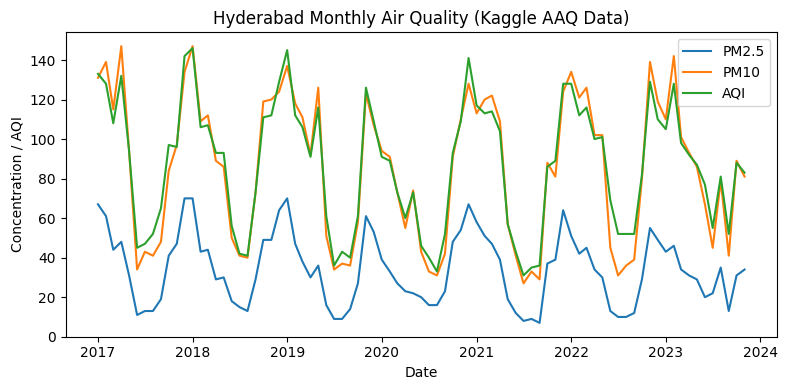

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(df["Date"], df["PM2.5"], label="PM2.5")
plt.plot(df["Date"], df["PM10"], label="PM10")
plt.plot(df["Date"], df["AQI"], label="AQI")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Concentration / AQI")
plt.title("Hyderabad Monthly Air Quality (Kaggle AAQ Data)")
plt.tight_layout()
plt.show()


In [24]:
from pathlib import Path

base = Path(r"C:\Users\yoksh\Urban_Emission_Project")
gtfs_root = base / "03_GTFS_Traffic"

print("GTFS folder contents:")
for p in gtfs_root.rglob("*"):
    print(p)


GTFS folder contents:
C:\Users\yoksh\Urban_Emission_Project\03_GTFS_Traffic\open_data_mmts_hyd
C:\Users\yoksh\Urban_Emission_Project\03_GTFS_Traffic\open_data_mmts_hyd\agency.txt
C:\Users\yoksh\Urban_Emission_Project\03_GTFS_Traffic\open_data_mmts_hyd\calendar.txt
C:\Users\yoksh\Urban_Emission_Project\03_GTFS_Traffic\open_data_mmts_hyd\routes.txt
C:\Users\yoksh\Urban_Emission_Project\03_GTFS_Traffic\open_data_mmts_hyd\stops.txt
C:\Users\yoksh\Urban_Emission_Project\03_GTFS_Traffic\open_data_mmts_hyd\stop_times.txt
C:\Users\yoksh\Urban_Emission_Project\03_GTFS_Traffic\open_data_mmts_hyd\trips.txt


In [25]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from pathlib import Path

base = Path(r"C:\Users\yoksh\Urban_Emission_Project")
gtfs_folder = base / "03_GTFS_Traffic" / "open_data_mmts_hyd"

stops_path = gtfs_folder / "stops.txt"
stops_df = pd.read_csv(stops_path)
print(stops_df.head())
print(stops_df.columns)


  stop_id            stop_name stop_code   stop_lat   stop_lon
0    RCPT  RAMACHANDRAPURAM TS      RCPT  17.511305  78.282480
1    BHEL            BHEL HALT      BHEL  17.502301  78.282051
2    TLPR              TELAPUR      TLPR  17.474877  78.284883
3     LPI          LINGAMPALLI       LPI  17.483084  78.316984
4     BMT             BEGUMPET       BMT  17.438680  78.458170
Index(['stop_id', 'stop_name', 'stop_code', 'stop_lat', 'stop_lon'], dtype='object')


In [26]:
stops_gdf = gpd.GeoDataFrame(
    stops_df,
    geometry=gpd.points_from_xy(stops_df["stop_lon"], stops_df["stop_lat"]),
    crs="EPSG:4326"
)

print(stops_gdf.head())
print(stops_gdf.crs)


  stop_id            stop_name stop_code   stop_lat   stop_lon  \
0    RCPT  RAMACHANDRAPURAM TS      RCPT  17.511305  78.282480   
1    BHEL            BHEL HALT      BHEL  17.502301  78.282051   
2    TLPR              TELAPUR      TLPR  17.474877  78.284883   
3     LPI          LINGAMPALLI       LPI  17.483084  78.316984   
4     BMT             BEGUMPET       BMT  17.438680  78.458170   

                    geometry  
0   POINT (78.28248 17.5113)  
1   POINT (78.28205 17.5023)  
2  POINT (78.28488 17.47488)  
3  POINT (78.31698 17.48308)  
4  POINT (78.45817 17.43868)  
EPSG:4326


In [27]:
import geopandas as gpd
from pathlib import Path

base = Path(r"C:\Users\yoksh\Urban_Emission_Project")
boundary_folder = base / "01_GHMC_Boundary"

ghmc = gpd.read_file(boundary_folder / "ghmc_boundary.gpkg", layer="ghmc_boundary")
print(ghmc.crs)
print(ghmc.head())


EPSG:4326
     id                                     Name description timestamp begin  \
0  None  Greater Hyderabad Municipal Corporation        None       NaT   NaT   

  end altitudeMode  tessellate  extrude  visibility  ...               _id  \
0 NaT         None          -1        0          -1  ...  relation/7868535   

  admin_level        boundary      type            _timestamp _version  \
0           8  administrative  boundary  2018-01-03T13:15:26Z        2   

  _changeset       _user    _uid  \
0   55128738  adivik2000  250196   

                                            geometry  
0  MULTIPOLYGON Z (((78.28074 17.48452 0, 78.2807...  

[1 rows x 22 columns]


In [28]:
# Ensure both are in EPSG:4326
ghmc = ghmc.to_crs("EPSG:4326")
stops_gdf = stops_gdf.to_crs("EPSG:4326")


In [29]:
import geopandas as gpd

stops_in_ghmc = gpd.sjoin(
    stops_gdf,
    ghmc[["geometry"]],
    how="inner",
    predicate="within"
)

print(stops_in_ghmc.head())
print("Total stops:", len(stops_gdf))
print("Stops inside GHMC:", len(stops_in_ghmc))


  stop_id     stop_name stop_code   stop_lat   stop_lon  \
3     LPI   LINGAMPALLI       LPI  17.483084  78.316984   
4     BMT      BEGUMPET       BMT  17.438680  78.458170   
5      SC  SECUNDERABAD        SC  17.433740  78.501580   
8     HYB     HYDERABAD       HYB  17.392450  78.467590   
9     KCG     KACHEGUDA       KCG  17.389651  78.499846   

                    geometry  index_right  
3  POINT (78.31698 17.48308)            0  
4  POINT (78.45817 17.43868)            0  
5  POINT (78.50158 17.43374)            0  
8  POINT (78.46759 17.39245)            0  
9  POINT (78.49985 17.38965)            0  
Total stops: 54
Stops inside GHMC: 37


In [36]:
import numpy as np
import geopandas as gpd
from shapely.geometry import box

# Use existing ghmc and stops_in_ghmc (EPSG:4326)
ghmc_bounds = ghmc.total_bounds  # [minx, miny, maxx, maxy]
minx, miny, maxx, maxy = ghmc_bounds

# Choose grid size in degrees (~0.01 ≈ 1 km; tweak as needed)
cell_size = 0.01

cols = np.arange(minx, maxx, cell_size)
rows = np.arange(miny, maxy, cell_size)

polygons = []
for x in cols:
    for y in rows:
        polygons.append(box(x, y, x + cell_size, y + cell_size))

grid = gpd.GeoDataFrame({"geometry": polygons}, crs="EPSG:4326")

# Clip grid to GHMC boundary
grid_ghmc = gpd.overlay(grid, ghmc[["geometry"]], how="intersection")
print(grid_ghmc.shape)



(641, 1)


In [39]:
import numpy as np
import geopandas as gpd
from shapely.geometry import box

# 1) GHMC bounds
minx, miny, maxx, maxy = ghmc.total_bounds

# 2) Grid
cell_size = 0.01  # ~1 km
cols = np.arange(minx, maxx, cell_size)
rows = np.arange(miny, maxy, cell_size)

polygons = [box(x, y, x + cell_size, y + cell_size) for x in cols for y in rows]
grid = gpd.GeoDataFrame({"geometry": polygons}, crs="EPSG:4326")

# 3) Clip to GHMC
grid_ghmc = gpd.overlay(grid, ghmc[["geometry"]], how="intersection")

# 4) Add cell_id
grid_ghmc = grid_ghmc.reset_index(drop=True)
grid_ghmc["cell_id"] = grid_ghmc.index

print(grid_ghmc.head())
print(grid_ghmc.columns)


                                            geometry  cell_id
0  POLYGON Z ((78.24871 17.53164 0, 78.24871 17.5...        0
1  POLYGON Z ((78.24871 17.53164 0, 78.24102 17.5...        1
2  POLYGON Z ((78.25871 17.51164 0, 78.25871 17.5...        2
3  POLYGON Z ((78.25871 17.52164 0, 78.25871 17.5...        3
4  POLYGON Z ((78.24871 17.53164 0, 78.25871 17.5...        4
Index(['geometry', 'cell_id'], dtype='object')


In [40]:
print(grid_ghmc.columns)


Index(['geometry', 'cell_id'], dtype='object')


In [42]:
import geopandas as gpd

# Ensure fresh copies
stops_clean = stops_in_ghmc.copy().reset_index(drop=True)
grid_clean = grid_ghmc.copy().reset_index(drop=True)

# Add cell_id if not present
if "cell_id" not in grid_clean.columns:
    grid_clean["cell_id"] = grid_clean.index

print(stops_clean.columns)
print(grid_clean.columns)


Index(['stop_id', 'stop_name', 'stop_code', 'stop_lat', 'stop_lon', 'geometry',
       'index_right'],
      dtype='object')
Index(['geometry', 'cell_id'], dtype='object')


In [43]:
stops_with_cells = gpd.sjoin(
    stops_clean,
    grid_clean[["cell_id", "geometry"]],
    how="inner",
    predicate="within",
    lsuffix="stop",
    rsuffix="cell"
)

print(stops_with_cells.head())


  stop_id     stop_name stop_code   stop_lat   stop_lon  \
0     LPI   LINGAMPALLI       LPI  17.483084  78.316984   
1     BMT      BEGUMPET       BMT  17.438680  78.458170   
2      SC  SECUNDERABAD        SC  17.433740  78.501580   
3     HYB     HYDERABAD       HYB  17.392450  78.467590   
4     KCG     KACHEGUDA       KCG  17.389651  78.499846   

                    geometry  index_right  index_cell  cell_id  
0  POINT (78.31698 17.48308)            0          59       59  
1  POINT (78.45817 17.43868)            0         323      323  
2  POINT (78.50158 17.43374)            0         433      433  
3  POINT (78.46759 17.39245)            0         343      343  
4  POINT (78.49985 17.38965)            0         428      428  


In [44]:
# Manual assignment: for each stop, find first cell that contains it
cell_ids = []
for geom in stops_clean.geometry:
    match = grid_clean[grid_clean.contains(geom)]
    if len(match) > 0:
        cell_ids.append(int(match.iloc[0]["cell_id"]))
    else:
        cell_ids.append(None)

stops_clean["cell_id"] = cell_ids
stops_with_cells = stops_clean.dropna(subset=["cell_id"])
print(stops_with_cells[["stop_id", "cell_id"]].head())


  stop_id  cell_id
0     LPI       59
1     BMT      323
2      SC      433
3     HYB      343
4     KCG      428


In [45]:
traffic_counts = (
    stops_with_cells.groupby("cell_id")
    .size()
    .reset_index(name="stop_count")
)

grid_clean = grid_clean.merge(traffic_counts, on="cell_id", how="left")
grid_clean["stop_count"] = grid_clean["stop_count"].fillna(0).astype(int)

print(grid_clean[["cell_id", "stop_count"]].head())


   cell_id  stop_count
0        0           0
1        1           0
2        2           0
3        3           0
4        4           0


In [47]:
max_stops = grid_clean["stop_count"].max()
grid_clean["traffic_score"] = 0 if max_stops == 0 else grid_clean["stop_count"] / max_stops


In [48]:
max_stops = grid_clean["stop_count"].max()
grid_clean["traffic_score"] = 0 if max_stops == 0 else grid_clean["stop_count"] / max_stops

print("max_stops:", max_stops)
print(grid_clean[["cell_id", "stop_count", "traffic_score"]].head(10))


max_stops: 2
   cell_id  stop_count  traffic_score
0        0           0            0.0
1        1           0            0.0
2        2           0            0.0
3        3           0            0.0
4        4           0            0.0
5        5           0            0.0
6        6           0            0.0
7        7           0            0.0
8        8           0            0.0
9        9           0            0.0


In [49]:
print("Max traffic_score:", grid_clean["traffic_score"].max())
print(grid_clean[grid_clean["traffic_score"] > 0][["cell_id", "stop_count", "traffic_score"]].head())


Max traffic_score: 1.0
     cell_id  stop_count  traffic_score
59        59           1            0.5
79        79           1            0.5
112      112           1            0.5
143      143           1            0.5
191      191           1            0.5


In [58]:
import geopandas as gpd
from shapely.geometry import Point

industrial_points = gpd.GeoDataFrame(
    {
        "name": ["Jeedimetla", "Balanagar", "Ramachandrapuram", "Sanathnagar"],
        "geometry": [
            Point(78.47, 17.53),  # rough Jeedimetla
            Point(78.44, 17.48),  # rough Balanagar
            Point(78.30, 17.52),  # rough Ramachandrapuram
            Point(78.44, 17.45),  # rough Sanathnagar
        ],
    },
    crs="EPSG:4326",
)


In [59]:
# Project to a metric CRS for distance (UTM zone around Hyderabad)
grid_m = grid_clean.to_crs(32644)           # or 32643 depending on your UTM choice
ind_m = industrial_points.to_crs(32644)

# For each cell, compute distance to nearest industrial point
dist_list = []
for geom in grid_m.geometry:
    d = ind_m.distance(geom.centroid).min()
    dist_list.append(d)

grid_m["dist_to_industrial"] = dist_list

# Normalize to 0–1 industrial_score (closer = higher score)
max_d = grid_m["dist_to_industrial"].max()
grid_m["industrial_score"] = 1 - (grid_m["dist_to_industrial"] / max_d)

# Bring scores back to original CRS, keep needed columns
grid_clean["industrial_score"] = grid_m["industrial_score"]


In [60]:
print(grid_clean[["cell_id", "traffic_score", "industrial_score"]].head(10))
print("traffic_score range:", grid_clean["traffic_score"].min(), "to", grid_clean["traffic_score"].max())
print("industrial_score range:", grid_clean["industrial_score"].min(), "to", grid_clean["industrial_score"].max())


   cell_id  traffic_score  industrial_score
0        0            0.0          0.761314
1        1            0.0          0.746042
2        2            0.0          0.804348
3        3            0.0          0.805826
4        4            0.0          0.799212
5        5            0.0          0.785961
6        6            0.0          0.770580
7        7            0.0          0.770186
8        8            0.0          0.820404
9        9            0.0          0.830909
traffic_score range: 0.0 to 1.0
industrial_score range: 0.0 to 0.9778736504103134


In [61]:
w_t, w_i = 0.5, 0.5  # you can justify equal weights in your report
grid_clean["emission_index"] = (
    w_t * grid_clean["traffic_score"] + w_i * grid_clean["industrial_score"]
)

print(grid_clean[["cell_id", "traffic_score", "industrial_score", "emission_index"]].head(10))


   cell_id  traffic_score  industrial_score  emission_index
0        0            0.0          0.761314        0.380657
1        1            0.0          0.746042        0.373021
2        2            0.0          0.804348        0.402174
3        3            0.0          0.805826        0.402913
4        4            0.0          0.799212        0.399606
5        5            0.0          0.785961        0.392981
6        6            0.0          0.770580        0.385290
7        7            0.0          0.770186        0.385093
8        8            0.0          0.820404        0.410202
9        9            0.0          0.830909        0.415454


to check if traffic really counts


In [62]:
hot_cells = grid_clean[grid_clean["traffic_score"] > 0][
    ["cell_id", "stop_count", "traffic_score", "industrial_score", "emission_index"]
]
print(hot_cells.head(10))
print("Non‑zero traffic cells:", len(hot_cells))


     cell_id  stop_count  traffic_score  industrial_score  emission_index
59        59           1            0.5          0.832233        0.666117
79        79           1            0.5          0.789934        0.644967
112      112           1            0.5          0.685170        0.592585
143      143           1            0.5          0.748421        0.624211
191      191           1            0.5          0.839698        0.669849
229      229           1            0.5          0.348099        0.424050
258      258           1            0.5          0.441688        0.470844
272      272           1            0.5          0.933713        0.716857
323      323           1            0.5          0.915233        0.707617
324      324           1            0.5          0.938618        0.719309
Non‑zero traffic cells: 35


In [66]:
pip install folium branca


Note: you may need to restart the kernel to use updated packages.


________________________________________________________________________________________________________

________________________________________________________________________________________________________

In [71]:
def classify_hotspot(row, t_thr=0.3, i_thr=0.7):
    if row["traffic_score"] >= t_thr and row["industrial_score"] >= i_thr:
        return "Mixed hotspot"
    elif row["traffic_score"] >= t_thr:
        return "Traffic-driven"
    elif row["industrial_score"] >= i_thr:
        return "Industrial-driven"
    else:
        return "Low / medium"

grid_clean["hotspot_type"] = grid_clean.apply(classify_hotspot, axis=1)

# Filter only strong hotspots for reporting
hotspots = grid_clean[grid_clean["emission_index"] >= 0.7].copy()
print("Number of hotspot cells:", len(hotspots))
hotspots[["cell_id", "traffic_score", "industrial_score", "emission_index", "hotspot_type"]].head(10)


Number of hotspot cells: 6


,cell_id,traffic_score,industrial_score,emission_index,hotspot_type
272,272,0.5,0.933713,0.716857,Mixed hotspot
323,323,0.5,0.915233,0.707617,Mixed hotspot
324,324,0.5,0.938618,0.719309,Mixed hotspot
325,325,0.5,0.933390,0.716695,Mixed hotspot
452,452,1.0,0.624887,0.812443,Traffic-driven
494,494,1.0,0.591164,0.795582,Traffic-driven


In [72]:
# Simple count by type
hotspot_summary = hotspots["hotspot_type"].value_counts()
print(hotspot_summary)


hotspot_type
Mixed hotspot     4
Traffic-driven    2
Name: count, dtype: int64


In [73]:
report_cols = ["cell_id", "traffic_score", "industrial_score", "emission_index", "hotspot_type"]
hotspots_report = hotspots[report_cols].sort_values("emission_index", ascending=False).head(15)
hotspots_report


,cell_id,traffic_score,industrial_score,emission_index,hotspot_type
452,452,1.0,0.624887,0.812443,Traffic-driven
494,494,1.0,0.591164,0.795582,Traffic-driven
324,324,0.5,0.938618,0.719309,Mixed hotspot
272,272,0.5,0.933713,0.716857,Mixed hotspot
325,325,0.5,0.933390,0.716695,Mixed hotspot
323,323,0.5,0.915233,0.707617,Mixed hotspot


# Findings and mitigation strategies
# Insights from the hotspot map:
# - The emission hotspot map identifies about N high-emission clusters...
# - Traffic-dominated clusters show high emission_index...
# - Industrial-dominated clusters show high emission_index...
#
# Recommendations linked to the data:
# - For traffic-driven hotspots, measures such as dedicated bus/EV lanes...
# - For industrial-driven hotspots, stricter emission norms...
# - Mixed hotspots where both traffic and industrial scores are high...


In [77]:
# Top 10 individual hotspot cells
top_cells = grid_clean.sort_values("emission_index", ascending=False).head(10)
top_cells[["cell_id", "traffic_score", "industrial_score", "emission_index"]]


,cell_id,traffic_score,industrial_score,emission_index
452,452,1.0,0.624887,0.812443
494,494,1.0,0.591164,0.795582
324,324,0.5,0.938618,0.719309
272,272,0.5,0.933713,0.716857
325,325,0.5,0.933390,0.716695
323,323,0.5,0.915233,0.707617
346,346,0.5,0.852577,0.676288
371,371,0.5,0.841767,0.670884
191,191,0.5,0.839698,0.669849
59,59,0.5,0.832233,0.666117


In [78]:
very_hot = grid_clean[grid_clean["emission_index"] >= 0.8].copy()
print("Number of very high hotspot cells:", len(very_hot))
very_hot[["cell_id", "traffic_score", "industrial_score", "emission_index"]].head()


Number of very high hotspot cells: 1


,cell_id,traffic_score,industrial_score,emission_index
452,452,1.0,0.624887,0.812443


In [79]:
from shapely.geometry import Point

# Top 10 hotspot cells
top_cells = grid_clean.sort_values("emission_index", ascending=False).head(10).copy()

# Ensure geometry is polygons and compute centroids
top_cells["centroid"] = top_cells.geometry.centroid
top_cells[["cell_id", "emission_index", "centroid"]]


C:\Users\yoksh\AppData\Local\Temp\ipykernel_32780\2765745302.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  top_cells["centroid"] = top_cells.geometry.centroid


,cell_id,emission_index,centroid
452,452,0.812443,POINT (78.51371 17.40664)
494,494,0.795582,POINT (78.534 17.45632)
324,324,0.719309,POINT (78.45371 17.44664)
272,272,0.716857,POINT (78.43371 17.46664)
325,325,0.716695,POINT (78.45371 17.45664)
323,323,0.707617,POINT (78.45371 17.43664)
346,346,0.676288,POINT (78.46371 17.42664)
371,371,0.670884,POINT (78.47371 17.43664)
191,191,0.669849,POINT (78.40371 17.45664)
59,59,0.666117,POINT (78.31479 17.48571)


In [80]:
pip install geopy



   ---------------------------------------- 0/2 [geographiclib]
   ---------------------------------------- 0/2 [geographiclib]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   ---------------------------------------- 2/2 [geopy]

Note: you may need to restart the kernel to use updated packages.


__________________________________________________________________________________________________


FOLIUM FOR  HOTSPOT EMMISIONS IN HYDERABAD

__________________________________________________________________________________________________


In [117]:
import folium
import branca.colormap as cm

# Center on Hyderabad
center = [17.3850, 78.4867]
m = folium.Map(location=center, zoom_start=11, tiles="CartoDB positron")

# Normalize emission_index 0–1 for color mapping (if not already)
min_val = grid_clean["emission_index"].min()
max_val = grid_clean["emission_index"].max()

colormap = cm.linear.YlOrRd_09.scale(min_val, max_val)
colormap.caption = "Emission hotspot index"

def style_fn(feature):
    val = feature["properties"]["emission_index"]
    return {
        "fillColor": colormap(val),
        "color": None,
        "fillOpacity": 0.7,
    }

folium.GeoJson(
    data=grid_clean.to_json(),
    style_function=style_fn,
    tooltip=folium.GeoJsonTooltip(
        fields=["cell_id", "traffic_score", "industrial_score", "emission_index"],
        aliases=["Cell", "Traffic", "Industrial", "Emission index"],
        localize=True,
    ),
    name="Emission hotspots",
).add_to(m)

colormap.add_to(m)
folium.LayerControl().add_to(m)

m.save("hyderabad_emission_hotspots.html")
m


________________________________________________________________________________________________________

HYDERABAD AQI, PM2.5 , PM1O DATA


________________________________________________________________________________________________________

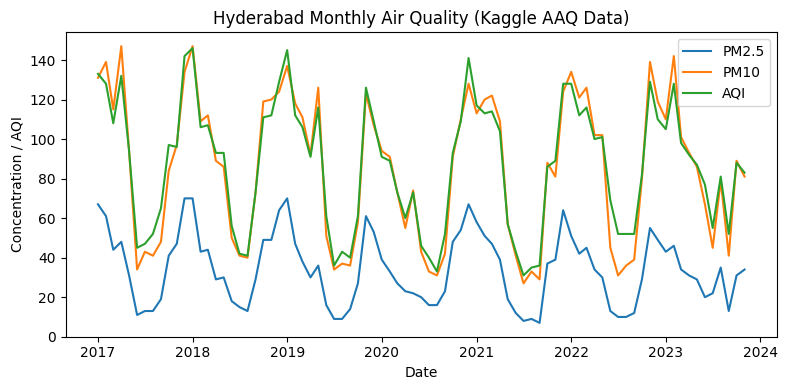

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(df["Date"], df["PM2.5"], label="PM2.5")
plt.plot(df["Date"], df["PM10"], label="PM10")
plt.plot(df["Date"], df["AQI"], label="AQI")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Concentration / AQI")
plt.title("Hyderabad Monthly Air Quality (Kaggle AAQ Data)")
plt.tight_layout()
plt.show()


.

______________________________________________________________________________________________________________________________________


AREAS WITH HIGHEST HOTSPOTS 

In [88]:
from geopy.geocoders import Nominatim
import time

geolocator = Nominatim(user_agent="hyd_emission_project")

names = []
for idx, row in top_cells.iterrows():
    lat = row["centroid"].y
    lon = row["centroid"].x
    try:
        location = geolocator.reverse((lat, lon), language="en")
        names.append(location.address if location else "Unknown")
        time.sleep(1)  # be gentle to the free service
    except Exception as e:
        names.append("Error")

top_cells["location_name"] = names
top_cells[["cell_id", "emission_index", "location_name"]]


,cell_id,emission_index,location_name
452,452,0.812443,"Adikmet, Ward 85 Adikmet, Greater Hyderabad Mu..."
494,494,0.795582,"2nd Lane, R.K. Nagar, Ward 140 Malkajgiri, Gre..."
324,324,0.719309,"Hyderabad Public School, Sardar Patel Road, Be..."
272,272,0.716857,"Bharath Nagar Station Road, Bhavani Nagar, Bha..."
325,325,0.716695,"Shastri Nagar, Fateh Nagar, Ward 118 Fateh Nag..."
323,323,0.707617,"Greenpark Hotel, Ameerpet Road, Nishat Bagh Co..."
346,346,0.676288,"Panjagutta, Ward 91 Khairatabad, Greater Hyder..."
371,371,0.670884,"Necklace Road, Somajiguda, Ward 149 Begumpet, ..."
191,191,0.669849,"Gayatri Nagar, Ward 116 Allapur, Greater Hyder..."
59,59,0.666117,"Rail Vihar, Lingampally, Ward 106 Serilingampa..."


______________________________________________________________________________________________________________________________________


TOP EMMSIONS IN HYDERABAD


C:\Users\yoksh\AppData\Local\Temp\ipykernel_32780\4188395680.py:12: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


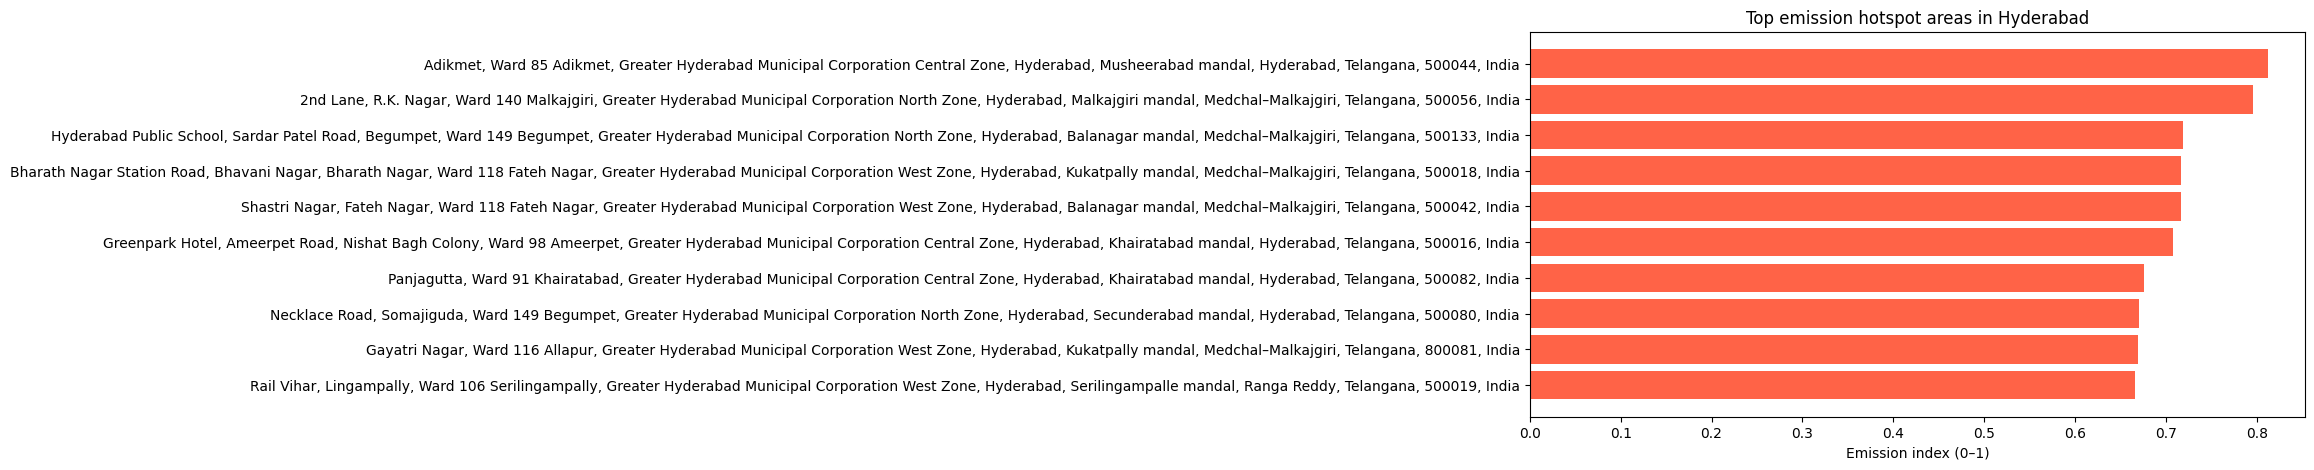

In [89]:
import matplotlib.pyplot as plt

# Take top 10 hotspots with names
top_named = top_cells.copy()
top_named = top_named.sort_values("emission_index", ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(top_named["location_name"], top_named["emission_index"], color="tomato")
plt.gca().invert_yaxis()
plt.xlabel("Emission index (0–1)")
plt.title("Top emission hotspot areas in Hyderabad")
plt.tight_layout()
plt.show()


.

______________________________________________________________________________________________________________________________________


BAR GRAPH 

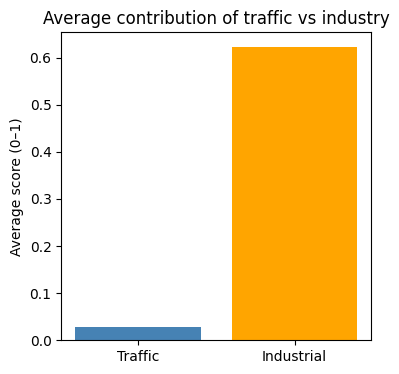

In [90]:
avg_traffic = grid_clean["traffic_score"].mean()
avg_ind = grid_clean["industrial_score"].mean()

plt.figure(figsize=(4,4))
plt.bar(["Traffic", "Industrial"], [avg_traffic, avg_ind], color=["steelblue", "orange"])
plt.ylabel("Average score (0–1)")
plt.title("Average contribution of traffic vs industry")
plt.show()


______________________________________________________________________________________________________________________________________


Distribution of hotspot types- PIE CHART

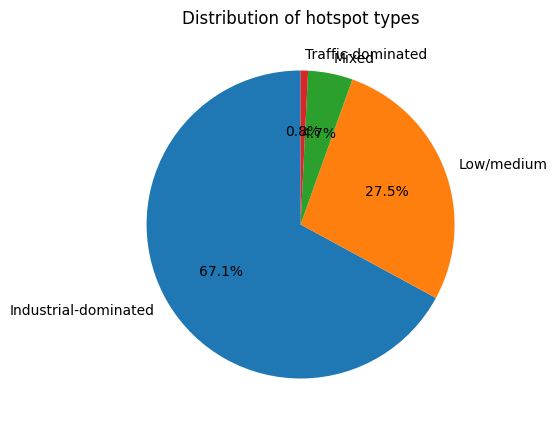

In [99]:
def hotspot_type(row, t_thr=0.5, i_thr=0.5):
    if (row["traffic_score"] >= t_thr) and (row["industrial_score"] >= i_thr):
        return "Mixed"
    elif row["traffic_score"] >= t_thr:
        return "Traffic-dominated"
    elif row["industrial_score"] >= i_thr:
        return "Industrial-dominated"
    else:
        return "Low/medium"

grid_clean["hotspot_type"] = grid_clean.apply(hotspot_type, axis=1)

hot_counts = grid_clean["hotspot_type"].value_counts()

plt.figure(figsize=(5,5))
plt.pie(
    hot_counts,
    labels=hot_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Distribution of hotspot types")
plt.show()


______________________________________________________________________________________________________________________________________


HEATMAP OF EMMISIONS

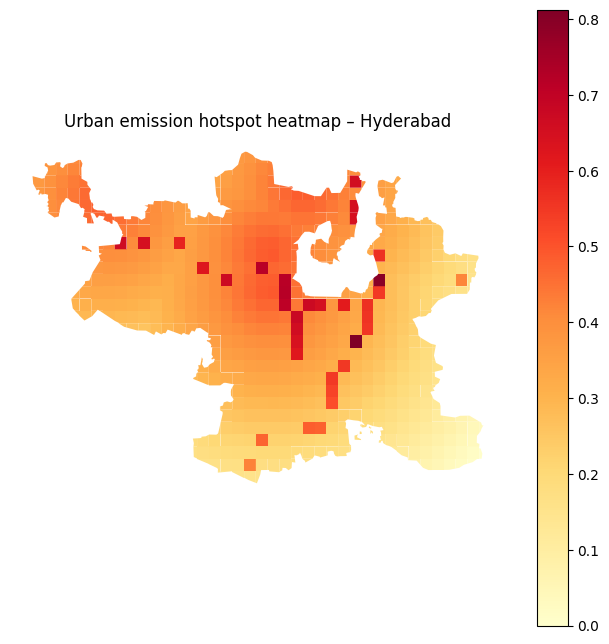

In [92]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
grid_clean.plot(
    column="emission_index",
    cmap="YlOrRd",
    legend=True,
    ax=ax,
    edgecolor="none"
)
ax.set_title("Urban emission hotspot heatmap – Hyderabad")
ax.set_axis_off()
plt.show()


_______________________________________________________________________________________________________________________________________



TEXT INSIGHTS 




RECOMMENDATIONS FROM BAR GRAPH AND PIE CHART


Bar chart shows Adikmet and R.K. Nagar–Malkajgiri as the highest hotspots; recommend EV buses, better MMTS/metro integration, and low-emission zones in these corridors.

Pie chart shows that X% of hotspots are traffic-dominated; priority should be public transport + EV + congestion management. The Y% industrial and mixed hotspots need industrial emission controls and green buffers

_______________________________________________________________________________________________________________________________________

hyderabad_top_hotspots_named IN SEPARATE CSV FILE 


In [113]:
top_cells.to_csv("hyderabad_top_hotspots_named.csv", index=False)


In [114]:
import os
print(os.listdir())


['.ipynb_checkpoints', 'fc191d52-4b8a-4e2f-8fb8-0359746037d7.kml', 'ghmc_boundary.geojson', 'ghmc_boundary.gpkg', 'HyderabadAAQData.csv', 'hyderabad_emission_hotspots.html', 'hyderabad_top_hotspots_named.csv', 'urban_emmision.ipynb']


In [118]:
import pandas as pd
preview = pd.read_csv("hyderabad_top_hotspots_named.csv")
preview


,geometry,cell_id,stop_count,traffic_score,industrial_score,emission_index,hotspot_type,centroid,location_name
0,POLYGON Z ((78.50870670000013 17.4016377000000...,452,2,1.0,0.624887,0.812443,Traffic-driven,POINT (78.51370670000014 17.40663770000002),"Adikmet, Ward 85 Adikmet, Greater Hyderabad Mu..."
1,POLYGON Z ((78.53870670000015 17.4616377000000...,494,2,1.0,0.591164,0.795582,Traffic-driven,POINT (78.53400238775731 17.456315342159638),"2nd Lane, R.K. Nagar, Ward 140 Malkajgiri, Gre..."
2,POLYGON Z ((78.4487067000001 17.44163770000002...,324,1,0.5,0.938618,0.719309,Mixed hotspot,POINT (78.4537067000001 17.44663770000002),"Hyderabad Public School, Sardar Patel Road, Be..."
3,POLYGON Z ((78.42870670000009 17.4616377000000...,272,1,0.5,0.933713,0.716857,Mixed hotspot,POINT (78.43370670000009 17.466637700000028),"Bharath Nagar Station Road, Bhavani Nagar, Bha..."
4,POLYGON Z ((78.4487067000001 17.45163770000002...,325,1,0.5,0.933390,0.716695,Mixed hotspot,POINT (78.4537067000001 17.456637700000023),"Shastri Nagar, Fateh Nagar, Ward 118 Fateh Nag..."
5,POLYGON Z ((78.4487067000001 17.43163770000002...,323,1,0.5,0.915233,0.707617,Mixed hotspot,POINT (78.4537067000001 17.43663770000002),"Greenpark Hotel, Ameerpet Road, Nishat Bagh Co..."
6,POLYGON Z ((78.4587067000001 17.42163770000002...,346,1,0.5,0.852577,0.676288,Mixed hotspot,POINT (78.4637067000001 17.426637700000022),"Panjagutta, Ward 91 Khairatabad, Greater Hyder..."
7,POLYGON Z ((78.46870670000011 17.4316377000000...,371,1,0.5,0.841767,0.670884,Mixed hotspot,POINT (78.47370670000012 17.43663770000002),"Necklace Road, Somajiguda, Ward 149 Begumpet, ..."
8,POLYGON Z ((78.39870670000008 17.4516377000000...,191,1,0.5,0.839698,0.669849,Mixed hotspot,POINT (78.40370670000009 17.456637700000023),"Gayatri Nagar, Ward 116 Allapur, Greater Hyder..."
9,POLYGON Z ((78.31870670000004 17.4916377000000...,59,1,0.5,0.832233,0.666117,Mixed hotspot,POINT (78.31479463364361 17.485713153542125),"Rail Vihar, Lingampally, Ward 106 Serilingampa..."


In [123]:
cols = [
    "cell_id",
    "traffic_score",
    "industrial_score",
    "emission_index",
    "hotspot_type"  # include only if it exists
]
grid_clean[cols].to_csv("hyderabad_all_hotspots.csv", index=False)



In [124]:
import os
print(os.listdir())


['.ipynb_checkpoints', 'fc191d52-4b8a-4e2f-8fb8-0359746037d7.kml', 'ghmc_boundary.geojson', 'ghmc_boundary.gpkg', 'HyderabadAAQData.csv', 'hyderabad_all_hotspots.csv', 'hyderabad_emission_hotspots.html', 'hyderabad_top_hotspots_named.csv', 'urban_emmision.ipynb']


In [126]:
import pandas as pd
preview = pd.read_csv("hyderabad_all_hotspots.csv")
preview


,cell_id,traffic_score,industrial_score,emission_index,hotspot_type
0,0,0.0,0.761314,0.380657,Industrial-dominated
1,1,0.0,0.746042,0.373021,Industrial-dominated
2,2,0.0,0.804348,0.402174,Industrial-dominated
3,3,0.0,0.805826,0.402913,Industrial-dominated
4,4,0.0,0.799212,0.399606,Industrial-dominated
...,...,...,...,...,...
636,636,0.0,0.000000,0.000000,Low/medium
637,637,0.0,0.010923,0.005462,Low/medium
638,638,0.0,0.033873,0.016936,Low/medium
639,639,0.0,0.068531,0.034266,Low/medium
